# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df =pd.read_csv("data.csv")

In [4]:
# Five first rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

In [3]:
# Age distribution

aga_summary = df["age"].describe()
aga_summary

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

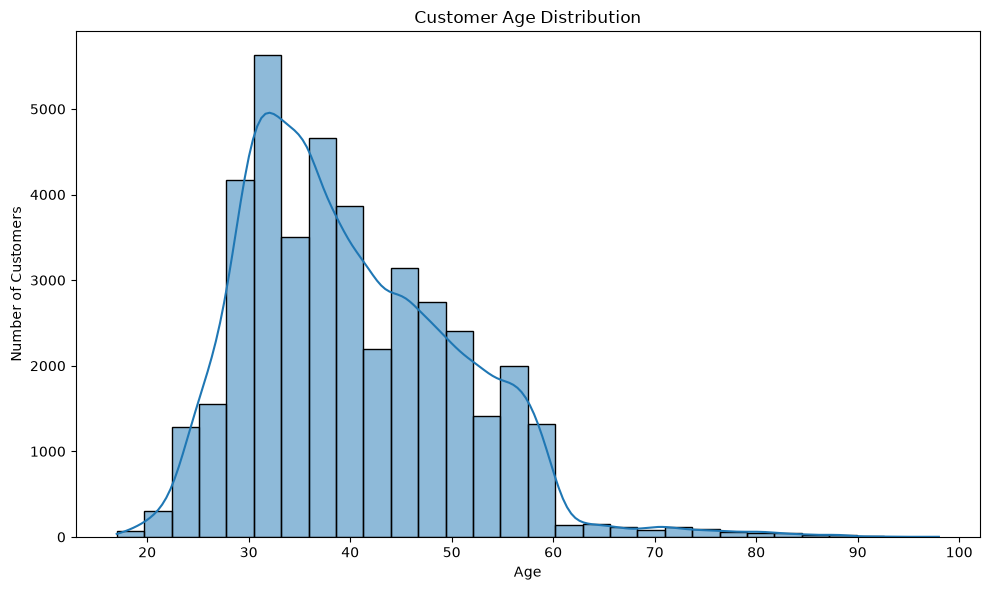

In [6]:
# Age Distribution Visualization
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [7]:
# Age Distribution by Subscription Outcome
age_by_subscription =(
    df.groupby("y")["age"]
      .agg(["count","mean","median","min","max"])
)
age_by_subscription

,count,mean,median,min,max
y,,,,,
no,36548,39.911185,38.0,17,95
yes,4640,40.913147,37.0,17,98


In [8]:
# Age Group Analysis
age_bins=[16,25,35,45,55,65,100]
age_labels=[
    "17-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_group_summary=(
    df["age_group"]
    .value_counts()
    .sort_index()
)

age_group_summary

age_group
17-25     1666
26-35    14847
36-45    12844
46-55     8249
56-65     2963
66+        619
Name: count, dtype: int64

In [9]:
# Subscription Rate by Age Group
age_subscription=pd.crosstab(
    df["age_group"],
    df["y"],
    normalize="index"
).mul(100)

age_subscription

y,no,yes
age_group,,
17-25,79.051621,20.948379
26-35,88.280461,11.719539
36-45,91.490190,8.509810
46-55,91.308037,8.691963
56-65,84.778940,15.221060
66+,53.150242,46.849758


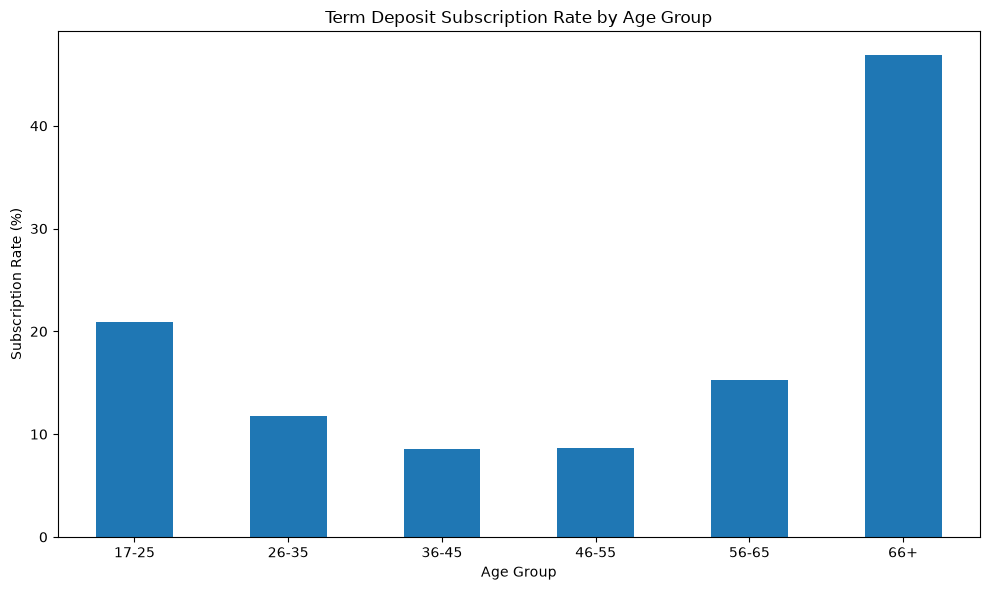

In [10]:
# Visualize Subscription Rate by Age Group
age_subscription["yes"].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# Job distribution
job_distribution=(
    df["job"]
    .value_counts()
)
job_distribution


job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

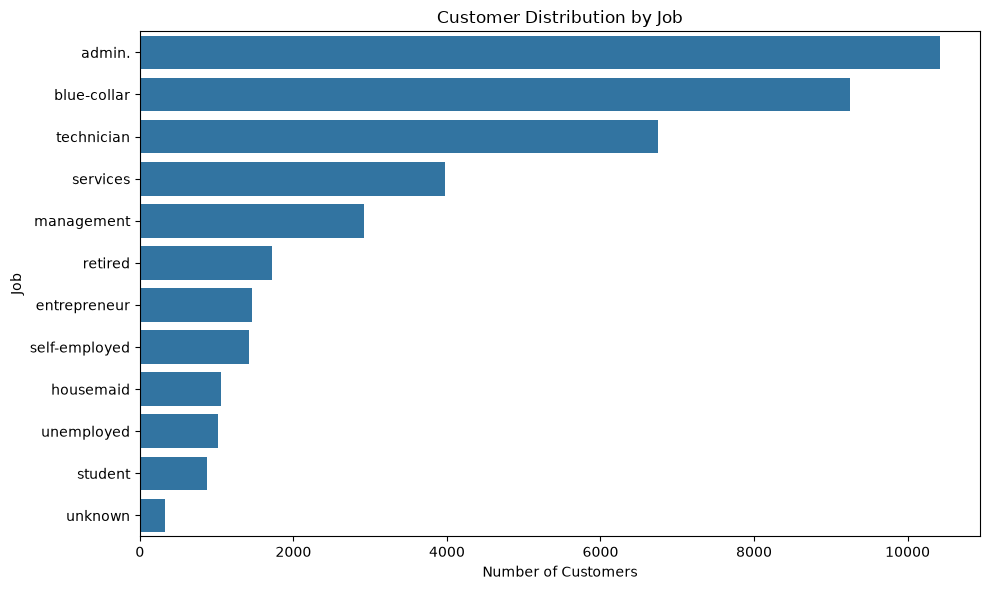

In [12]:
# Job Distribution Visualization
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

In [13]:
# Job Distribution and Subscription Outcome
job_subscription = pd.crosstab(
    df["job"],
    df["y"]
)

job_subscription

y,no,yes
job,,
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323
student,600,275


In [ ]:
# Subscription Rate by Job
job_subscription_rate=pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
).mul(100)

job_subscription_rate

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


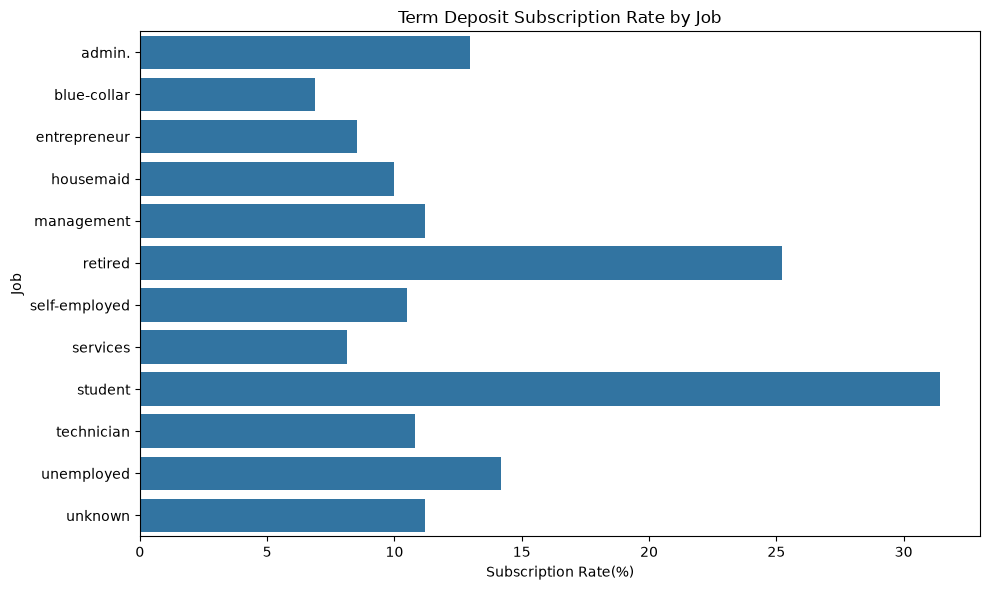

In [16]:
# Visualise Job Subscription Rate
plt.figure(figsize=(10,6))

sns.barplot(
    data=(
        job_subscription_rate
        .reset_index()
        .rename(columns={"yes":"subscription_rate"})
    ),
    x="subscription_rate",
    y="job"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate(%)")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

## Balance & Deposit Trends

In [ ]:
# Average balance by deposit subscription


## Campaign Effectiveness

In [ ]:
# Contact method analysis


In [ ]:
# Number of contacts vs deposit subscription


## Correlation Heatmap

In [ ]:
# Correlation of numerical variables


## Predictive Modeling (Logistic Regression)

In [ ]:


# Encode categorical variables

# Predictions


In [ ]:
# Feature importance


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.